#  Email Spam Detection using Machine Learning

## Oasis Infobyte Internship (OIBSIP) - Task 4

### Objective
The objective of this project is to build a Natural Language Processing (NLP) model capable of classifying text messages as **Spam** or **Ham (Not Spam)**. The project involves preprocessing textual data, converting text into numerical features using TF-IDF Vectorization, training multiple machine learning models, and evaluating their performance using various classification metrics.

## Importing Required Libraries

In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from wordcloud import WordCloud

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\biswa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading the Dataset

In [6]:
df = pd.read_csv("spam.csv", encoding="latin-1")

In [7]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


## Data Cleaning and Dataset Exploration

In [8]:
# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Display first five rows
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display information about the dataset
df.info()

Dataset Shape: (5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [10]:
# Check for missing values
df.isnull().sum()

label      0
message    0
dtype: int64

## EDA

In [11]:
# Display the number of spam and ham messages
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


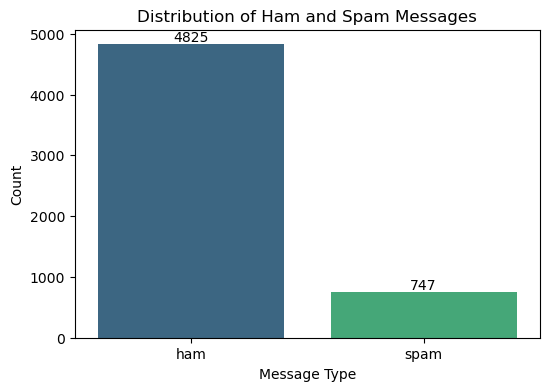

In [13]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="label",
    hue="label",
    data=df,
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Ham and Spam Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

## Text Preprocessing

In [15]:
# Load English stopwords
stop_words = set(stopwords.words("english"))

In [16]:
def preprocess(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [17]:
# Apply preprocessing to all messages
df["clean_message"] = df["message"].apply(preprocess)

# Display the first five rows
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Feature Extraction using TF-IDF Vectorization

Machine learning algorithms cannot understand text directly. Therefore, we need to convert the cleaned text into numerical features.

In this project, we use **TF-IDF (Term Frequency-Inverse Document Frequency) Vectorization**.

### What is TF-IDF?

TF-IDF is a technique that assigns a numerical weight to each word in a document based on two factors:

- **Term Frequency (TF):** Measures how frequently a word appears in a message.
- **Inverse Document Frequency (IDF):** Reduces the importance of words that appear in many messages and increases the importance of words that are unique.

As a result, commonly used words receive lower weights, while words that help distinguish spam from ham receive higher weights.

The output of TF-IDF is a numerical feature matrix that can be used to train machine learning models.

In [18]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)

# Convert text into numerical features
X = tfidf.fit_transform(df["clean_message"])

# Target variable
y = df["label"]

In [19]:
print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5572, 5000)


## Train-Test Split

In [20]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print("Training Feature Shape :", X_train.shape)
print("Testing Feature Shape  :", X_test.shape)

print("\nTraining Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Feature Shape : (4457, 5000)
Testing Feature Shape  : (1115, 5000)

Training Labels : (4457,)
Testing Labels  : (1115,)


## Training models 

### Multinomial Naive Bayes

In [26]:
# Create the Multinomial Naive Bayes model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train, y_train)

# Predict labels for the test dataset
y_pred_nb = nb_model.predict(X_test)

### Logistic Regression

In [25]:
# Create the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred_lr = lr_model.predict(X_test)

### Support Vector Machine (Linear SVM)

In [32]:
# Create the Linear SVM model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train, y_train)

# Predict on the test set
y_pred_svm = svm_model.predict(X_test)

## Evaluation

In [34]:
def evaluate_model(model_name, y_true, y_pred):

    print("=" * 60)
    print(f"{model_name} Evaluation")
    print("=" * 60)

    # Calculate Metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, pos_label='spam')
    recall = recall_score(y_true, y_pred, pos_label='spam')
    f1 = f1_score(y_true, y_pred, pos_label='spam')

    # Print Metrics
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")

    # Classification Report
    print("\nClassification Report:\n")
    print(classification_report(y_true, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Ham", "Spam"],
        yticklabels=["Ham", "Spam"]
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

Multinomial Naive Bayes Evaluation
Accuracy : 0.9722
Precision: 1.0000
Recall   : 0.7933
F1-Score : 0.8848

Classification Report:

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       965
        spam       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



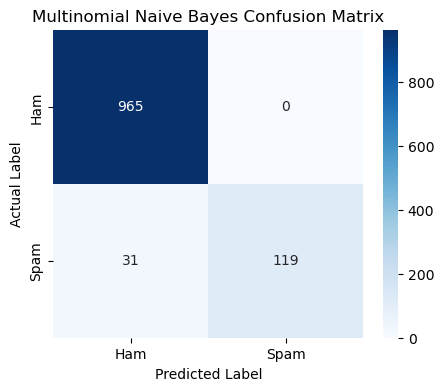

Logistic Regression Evaluation
Accuracy : 0.9489
Precision: 0.9604
Recall   : 0.6467
F1-Score : 0.7729

Classification Report:

              precision    recall  f1-score   support

         ham       0.95      1.00      0.97       965
        spam       0.96      0.65      0.77       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115



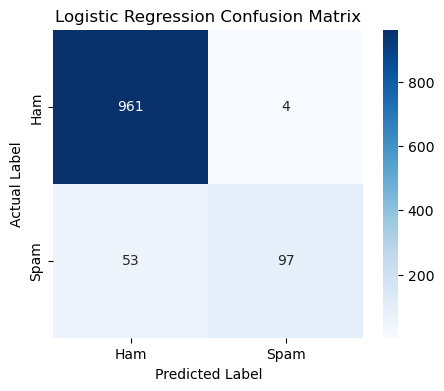

Linear SVM Evaluation
Accuracy : 0.9767
Precision: 0.9769
Recall   : 0.8467
F1-Score : 0.9071

Classification Report:

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.98      0.85      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



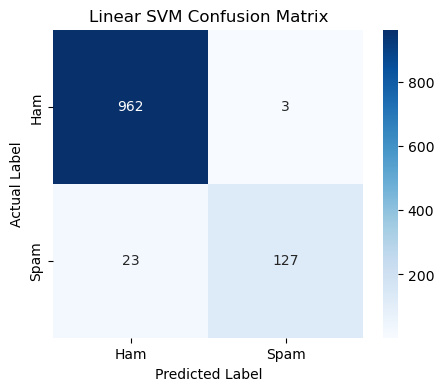

In [35]:
evaluate_model("Multinomial Naive Bayes", y_test, y_pred_nb)
evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Linear SVM", y_test, y_pred_svm)

In [36]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Precision": [
        precision_score(y_test, y_pred_nb, pos_label='spam'),
        precision_score(y_test, y_pred_lr, pos_label='spam'),
        precision_score(y_test, y_pred_svm, pos_label='spam')
    ],
    "Recall": [
        recall_score(y_test, y_pred_nb, pos_label='spam'),
        recall_score(y_test, y_pred_lr, pos_label='spam'),
        recall_score(y_test, y_pred_svm, pos_label='spam')
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_nb, pos_label='spam'),
        f1_score(y_test, y_pred_lr, pos_label='spam'),
        f1_score(y_test, y_pred_svm, pos_label='spam')
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.972197,1.000000,0.793333,0.884758
1,Logistic Regression,0.948879,0.960396,0.646667,0.772908
2,Linear SVM,0.976682,0.976923,0.846667,0.907143


**Recall** is especially important in spam detection because it measures how many actual spam messages are correctly identified. A high recall reduces the number of spam messages that reach the user's inbox.

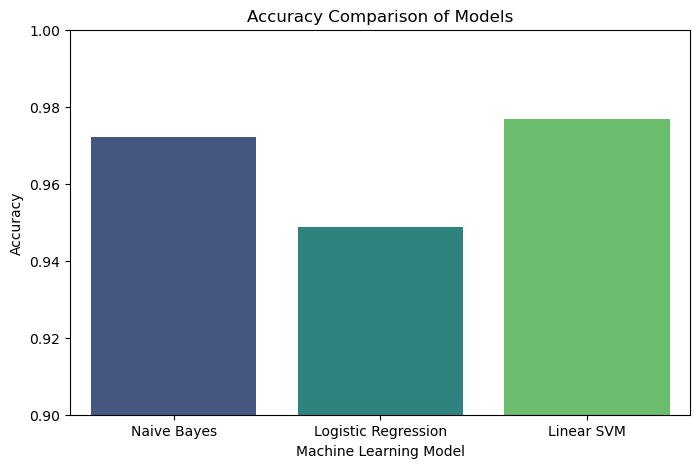

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Accuracy Comparison of Models")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.00)

plt.show()

## Word Cloud Visualization

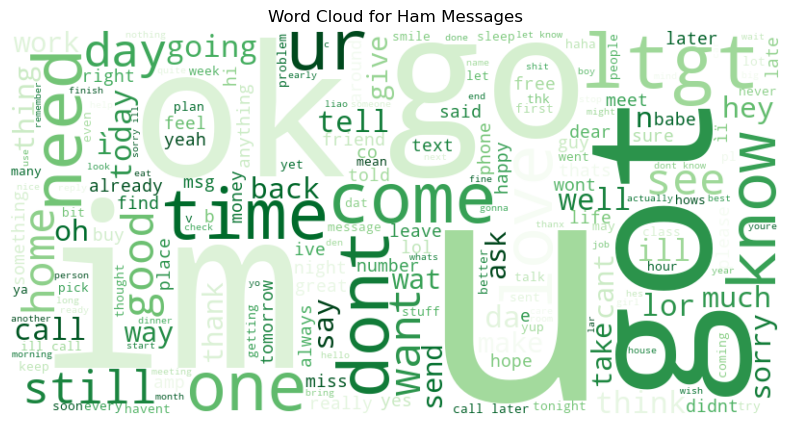

In [38]:
# Combine all ham messages into a single string
ham_words = " ".join(df[df["label"] == "ham"]["clean_message"])

# Generate Word Cloud
ham_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Greens"
).generate(ham_words)

# Display
plt.figure(figsize=(10,5))
plt.imshow(ham_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Ham Messages")
plt.show()

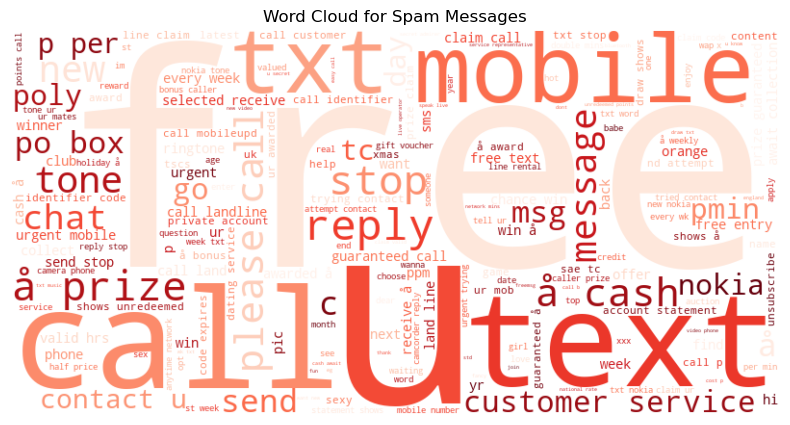

In [39]:
# Combine all spam messages into a single string
spam_words = " ".join(df[df["label"] == "spam"]["clean_message"])

# Generate Word Cloud
spam_wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="Reds"
).generate(spam_words)

# Display
plt.figure(figsize=(10,5))
plt.imshow(spam_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Spam Messages")
plt.show()

# Conclusion

In this project, an Email Spam Detection system was developed using Natural Language Processing (NLP) and Machine Learning techniques. The SMS dataset was preprocessed by cleaning the text, removing stopwords, and converting messages into numerical features using **TF-IDF Vectorization**.

Three machine learning models—**Multinomial Naive Bayes**, **Logistic Regression**, and **Linear Support Vector Machine (SVM)**—were trained and evaluated using Accuracy, Precision, Recall, and F1-Score. The comparison showed that all models achieved high performance in classifying spam and ham messages, with **Linear SVM and Logistic Regression** generally providing the best overall results.

Word Cloud visualizations further highlighted the differences between spam and legitimate messages by displaying the most frequent words in each category.

Overall, this project demonstrates how machine learning can effectively automate spam detection, helping filter unwanted messages while improving the security and reliability of email and messaging systems.